In [19]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

df = pd.read_csv("./data/Diamonds/diamonds.csv.bz2")

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [20]:
# price = carat * a + x * b + c
# model should learn a, b, c

from sklearn.linear_model import LinearRegression

model = LinearRegression()

X_train = df[["carat", "x"]]
y_train = df["price"]

model.fit(X_train, y_train)

a = model.coef_[0]
b = model.coef_[1]
c = model.intercept_

print(f"price = carat * {a:.2f} + x * {b:.2f} + {c:.2f}")

price = carat * 10125.99 + x * -1026.86 + 1737.95


In [21]:
X_pred = np.array([
    [0.5, 5],
    [0.25, 3],
])

y_pred = model.predict(X_pred)
print(y_pred)

[1666.65930266 1188.87609325]


/home/sven/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


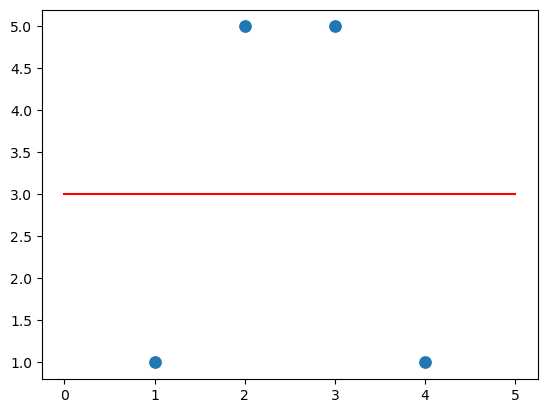

In [22]:
line_y = 3

xs = [1, 2, 3, 4]
ys = [1, 5, 5, 1]

ax = sns.scatterplot(x = xs, y = ys, s = 100)
sns.lineplot(x = [0, 5], y = [line_y, line_y], ax = ax, color = "red")
plt.show()

In [23]:
# line_y = 3 => E = 16
# line_y = 4 => E = 20

# quadratischer Fehler sorgt dafür, dass große Abweichungen stärker bestraft werden

$$E = \sum (\hat y - y)²$$